# Concrete Bridge Deck Crack Detection — Cracked vs Non-Cracked

**Dataset:** [SDNET2018 (aniruddhsharma mirror)](https://www.kaggle.com/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images) — Deck subset only.

## Design decisions and why (read before you run this blind)

1. **Deck only.** We filter to the Deck folder at load time and verify counts live — don't trust the numbers you eyeballed on the Kaggle page, this notebook counts the actual files.
2. **Group-aware splitting.** SDNET2018 patches are crops from a smaller number of source bridge-deck photographs. A naive random split lets near-duplicate patches from the *same source photo* leak across train/val/test, inflating test metrics without the model learning anything generalizable. We extract a group ID from the filename prefix and use `GroupShuffleSplit` so an entire source photo's patches stay in one split only.
3. **2:1 undersampling (Non-cracked : Cracked), done at the group level.** We don't undersample individual images — we drop whole groups (source photos) so we never accidentally leave partial, leaky remnants of a group in the dataset. This is your stated choice; the notebook also computes `class_weight` as an alternative so you can compare against training on the *full* dataset with weighted loss instead of throwing away ~7,500 non-cracked images. Test both before you commit to a final approach in your writeup — undersampling to a ratio you picked without justification is not automatically the right call.
4. **Two models, trained and evaluated identically:** a custom CNN baseline, and a transfer-learning model (EfficientNetV2-B0). The baseline exists so the transfer-learning result means something — if EfficientNet only marginally beats a simple CNN, that's a real finding, not a footnote.
5. **Evaluation on the held-out test set only reports metrics you'd defend in a review:** accuracy, precision, recall, F1, ROC-AUC, PR-AUC, confusion matrix. Accuracy alone is not acceptable for this problem — the whole point of fixing the imbalance is so precision/recall on the crack class are trustworthy.


## 1. Setup

In [1]:
# If running in Colab / Kaggle, uncomment:
# !pip install -q tensorflow scikit-learn pandas matplotlib seaborn opencv-python-headless

import os, re, random, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    balanced_accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)   # matches EfficientNetV2-B0 default input
BATCH_SIZE = 32
UNDERSAMPLE_RATIO = 2.0  # Non-cracked : Cracked target ratio
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Get the data

Run **one** of the two cells below.

- Cell A: Kaggle API (needs `kaggle.json` uploaded / `KAGGLE_USERNAME` + `KAGGLE_KEY` env vars set). This is the reproducible way — use it.
- Cell B: manual — if you've already downloaded and unzipped the dataset yourself, just set `DATASET_ROOT` to point at it and skip Cell A.


In [2]:
# --- Cell A: Kaggle API download (skip if you already have the data) ---
DATASET_ROOT = "./structural-defects-network-concrete-crack-images"

if not os.path.exists(DATASET_ROOT):
    os.makedirs(DATASET_ROOT, exist_ok=True)
    # Requires kaggle.json in ~/.kaggle/ or KAGGLE_USERNAME/KAGGLE_KEY env vars
    os.system(
        "kaggle datasets download -d aniruddhsharma/structural-defects-network-concrete-crack-images "
        f"-p {DATASET_ROOT} --unzip"
    )
    print("Downloaded and unzipped to", DATASET_ROOT)
else:
    print("Found existing folder, skipping download:", DATASET_ROOT)


Downloaded and unzipped to ./structural-defects-network-concrete-crack-images


In [3]:
# --- Cell B: manual override (uncomment and set your own path if not using Kaggle API) ---
# DATASET_ROOT = "/path/to/your/already-downloaded/dataset"


In [4]:
# Locate the Deck folder robustly (folder naming can vary slightly between mirrors)
def find_folder(root, name_contains):
    matches = []
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if name_contains.lower() in d.lower():
                matches.append(os.path.join(dirpath, d))
    return matches

deck_candidates = find_folder(DATASET_ROOT, "deck")
if not deck_candidates:
    raise FileNotFoundError(
        f"No folder containing 'deck' found under {DATASET_ROOT}. "
        "List the directory tree and adjust find_folder / DATASET_ROOT."
    )
DECK_ROOT = deck_candidates[0]
print("Using Deck folder:", DECK_ROOT)

for dirpath, dirnames, filenames in os.walk(DECK_ROOT):
    if filenames:
        print(f"  {dirpath}: {len(filenames)} files")


Using Deck folder: ./structural-defects-network-concrete-crack-images/Decks
  ./structural-defects-network-concrete-crack-images/Decks/Cracked: 2025 files
  ./structural-defects-network-concrete-crack-images/Decks/Non-cracked: 11595 files


## 3. Build a manifest (filepath, label, group_id) and verify the raw class counts

In [5]:
def classify_subfolder(dirname):
    """Map a subfolder name to Cracked / Non-cracked. Adjust patterns if your
    mirror uses different naming (e.g. 'CD'/'UD' codes instead of words)."""
    d = dirname.lower()
    if "non" in d or d in ("ud", "uncracked"):
        return "Non-cracked"
    if "crack" in d or d in ("cd",):
        return "Cracked"
    return None

rows = []
for dirpath, dirnames, filenames in os.walk(DECK_ROOT):
    label = classify_subfolder(os.path.basename(dirpath))
    if label is None:
        continue
    for f in filenames:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            rows.append({"filepath": os.path.join(dirpath, f), "label": label})

manifest = pd.DataFrame(rows)
assert len(manifest) > 0, "No images found — check DECK_ROOT / classify_subfolder logic."
print("RAW Deck-only counts (verify this against what you expected):")
print(manifest["label"].value_counts())


RAW Deck-only counts (verify this against what you expected):
label
Non-cracked    11595
Cracked         2025
Name: count, dtype: int64


In [6]:
# --- Group ID extraction for leakage-safe splitting ---
# SDNET-style filenames look like "7001-99.jpg": the prefix before the last
# "-<number>.<ext>" groups patches cropped from the same source photograph.
# If your files don't follow this pattern, this falls back to using the
# filename itself as its own group (i.e. no grouping / worst case = random split),
# so check the printed sample below and adjust the regex if needed.

def extract_group_id(filepath):
    fname = os.path.basename(filepath)
    m = re.match(r"^([A-Za-z0-9]+?)-\d+\.\w+$", fname)
    if m:
        return m.group(1)
    return fname

manifest["group_id"] = manifest["filepath"].apply(extract_group_id)

n_unique_groups = manifest["group_id"].nunique()
n_images = len(manifest)
print(f"Images: {n_images}, unique groups extracted: {n_unique_groups}")
print("Sample filenames -> extracted group:")
print(manifest[["filepath", "group_id"]].sample(5, random_state=SEED))

if n_unique_groups == n_images:
    print("\nWARNING: every image got its own group id — the filename regex did not "
          "match this dataset's naming convention, so grouping is a no-op. "
          "Inspect actual filenames and fix extract_group_id before trusting the split.")


Images: 13620, unique groups extracted: 66
Sample filenames -> extracted group:
                                                filepath group_id
6220   ./structural-defects-network-concrete-crack-im...     7019
12053  ./structural-defects-network-concrete-crack-im...     7014
8521   ./structural-defects-network-concrete-crack-im...     7044
6225   ./structural-defects-network-concrete-crack-im...     7023
3482   ./structural-defects-network-concrete-crack-im...     7050


## 4. Group-aware undersampling of Non-cracked to the target ratio

We drop whole groups (source photos), never individual images from a group, so no group ends up
split between "kept" and "dropped" in a way that could still leak structure.


In [7]:
def group_aware_undersample(df, minority_label, majority_label, ratio, seed=SEED):
    rng = np.random.RandomState(seed)
    minority_df = df[df.label == minority_label]
    majority_df = df[df.label == majority_label]
    target_n = int(len(minority_df) * ratio)

    maj_groups = majority_df["group_id"].unique().tolist()
    rng.shuffle(maj_groups)

    kept_groups, running_total = [], 0
    for g in maj_groups:
        if running_total >= target_n:
            break
        kept_groups.append(g)
        running_total += (majority_df.group_id == g).sum()

    majority_kept = majority_df[majority_df.group_id.isin(kept_groups)]
    result = pd.concat([minority_df, majority_kept], ignore_index=True)
    return result

balanced = group_aware_undersample(manifest, "Cracked", "Non-cracked", ratio=UNDERSAMPLE_RATIO)
print("Balanced counts (target ratio {:.1f}:1):".format(UNDERSAMPLE_RATIO))
print(balanced["label"].value_counts())
achieved_ratio = (balanced.label == "Non-cracked").sum() / (balanced.label == "Cracked").sum()
print(f"Achieved ratio: {achieved_ratio:.2f}")

# Alternative for comparison: full data + class weights (don't skip evaluating this)
classes = np.array(["Cracked", "Non-cracked"])
class_weights_full = compute_class_weight(
    class_weight="balanced", classes=classes,
    y=manifest["label"].values
)
class_weight_dict_full = {i: w for i, w in enumerate(class_weights_full)}
print("\nFor reference — class weights if you trained on the FULL dataset instead:", class_weight_dict_full)


Balanced counts (target ratio 2.0:1):
label
Non-cracked    4110
Cracked        2025
Name: count, dtype: int64
Achieved ratio: 2.03

For reference — class weights if you trained on the FULL dataset instead: {0: np.float64(3.362962962962963), 1: np.float64(0.5873221216041398)}


## 5. Group-aware, stratified train / val / test split (70 / 15 / 15)

**Fixed after real-data testing:** the data has only **66 unique source-photo groups** for the whole Deck
subset, and each group contains *both* Cracked and Non-cracked patches (same photo, different crops).
Splitting each class's groups independently — the first version of this cell — let a group show up in
train for one class and val for the other, which the leakage assertion below correctly caught. The fix is
to split at the group level across the *whole* balanced set at once, using `StratifiedGroupKFold` so class
balance is preserved as well as group integrity is respected.



In [8]:
def stratified_group_split(df, test_frac=0.15, val_frac=0.15, seed=SEED):
    """Single group-level, class-stratified split across the WHOLE dataset at once.
    Critical: must NOT be done per-class separately when the same group_id appears
    in both classes (true here: 66 groups hold both Cracked and Non-cracked patches),
    or a group can leak across splits via the other class."""
    y = df["label"].values
    groups = df["group_id"].values

    n_splits_test = max(2, round(1 / test_frac))
    sgkf1 = StratifiedGroupKFold(n_splits=n_splits_test, shuffle=True, random_state=seed)
    trainval_idx, test_idx = next(sgkf1.split(df, y, groups))
    trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
    test_df = df.iloc[test_idx].reset_index(drop=True)

    val_relative = val_frac / (1 - test_frac)
    n_splits_val = max(2, round(1 / val_relative))
    sgkf2 = StratifiedGroupKFold(n_splits=n_splits_val, shuffle=True, random_state=seed)
    train_idx, val_idx = next(sgkf2.split(trainval_df, trainval_df["label"].values, trainval_df["group_id"].values))
    train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
    val_df = trainval_df.iloc[val_idx].reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = stratified_group_split(balanced)

print("Split sizes -> train:", len(train_df), "val:", len(val_df), "test:", len(test_df))
for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} balance:\n{d.label.value_counts()}")
    print(f"{name} n_groups: {d.group_id.nunique()}")

# Hard verification: zero group leakage. If this fails, DO NOT proceed to training.
tg, vg, teg = set(train_df.group_id), set(val_df.group_id), set(test_df.group_id)
assert tg.isdisjoint(vg), "LEAKAGE: train/val share source-photo groups"
assert tg.isdisjoint(teg), "LEAKAGE: train/test share source-photo groups"
assert vg.isdisjoint(teg), "LEAKAGE: val/test share source-photo groups"
print("\nVerified: no group leakage across train/val/test.")

# With only ~66 groups total, seriously consider replacing this single split with
# repeated StratifiedGroupKFold runs (different seeds, or full k-fold CV) and
# reporting mean +/- std of test metrics in Section 11 instead of one number.


Split sizes -> train: 4767 val: 921 test: 447

Train balance:
label
Non-cracked    3237
Cracked        1530
Name: count, dtype: int64
Train n_groups: 44

Val balance:
label
Non-cracked    647
Cracked        274
Name: count, dtype: int64
Val n_groups: 8

Test balance:
label
Non-cracked    226
Cracked        221
Name: count, dtype: int64
Test n_groups: 9

Verified: no group leakage across train/val/test.


## 6. tf.data pipelines

In [9]:
LABEL_MAP = {"Non-cracked": 0, "Cracked": 1}

def make_dataset(df, training=False):
    paths = df["filepath"].values
    labels = df["label"].map(LABEL_MAP).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_img(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 2000), seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")


## 7. Models

**Baseline: custom CNN.** Exists so the transfer-learning result is measured against something, not just against "no model."

**Transfer learning: EfficientNetV2-B0**, ImageNet weights, base frozen initially then fine-tuned.


In [10]:
def build_custom_cnn(input_shape=(*IMG_SIZE, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    for filters in [32, 64, 128, 256]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="custom_cnn")

def build_transfer_model(input_shape=(*IMG_SIZE, 3), fine_tune=False):
    base = tf.keras.applications.EfficientNetV2B0(
        include_top=False, weights="imagenet", input_shape=input_shape
    )
    base.trainable = fine_tune
    inputs = tf.keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet_v2.preprocess_input(x * 255.0)
    x = base(x, training=fine_tune)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs, name="efficientnetv2b0")
    return model, base

METRICS = [
    tf.keras.metrics.BinaryAccuracy(name="accuracy"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall"),
    tf.keras.metrics.AUC(name="auc"),
    tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
]


## 8. Train the custom CNN baseline

In [11]:
custom_cnn = build_custom_cnn()
custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=METRICS
)
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
callbacks_cnn = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4),
    tf.keras.callbacks.ModelCheckpoint("best_custom_cnn.keras", monitor="val_auc", mode="max", save_best_only=True),
]

history_cnn = custom_cnn.fit(
    train_ds, validation_data=val_ds,
    epochs=40, callbacks=callbacks_cnn
)


Epoch 1/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.6939 - auc: 0.6468 - loss: 0.6198 - pr_auc: 0.4755 - precision: 0.5392 - recall: 0.3190 - val_accuracy: 0.7025 - val_auc: 0.6038 - val_loss: 0.6074 - val_pr_auc: 0.3794 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - accuracy: 0.6879 - auc: 0.6248 - loss: 0.6194 - pr_auc: 0.4539 - precision: 0.5276 - recall: 0.2621 - val_accuracy: 0.7025 - val_auc: 0.4395 - val_loss: 0.7494 - val_pr_auc: 0.2506 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.6950 - auc: 0.6442 - loss: 0.6058 - pr_auc: 0.4758 - precision: 0.5480 - recall: 0.2837 - val_accuracy: 0.7025 - val_auc: 0.4653 - val_loss: 0.6816 - val_pr_auc: 0.2628 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/40
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 137ms/step 

## 9. Train EfficientNetV2-B0 (frozen base, then fine-tune)

In [13]:
effnet, effnet_base = build_transfer_model(fine_tune=False)
effnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=METRICS
)

callbacks_head = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
]

history_head = effnet.fit(
    train_ds, validation_data=val_ds,
    epochs=15, callbacks=callbacks_head
)


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 35s 126ms/step - accuracy: 0.6468 - auc: 0.5980 - loss: 1.4516 - pr_auc: 0.3915 - precision: 0.4494 - recall: 0.5044 - val_accuracy: 0.6536 - val_auc: 0.5062 - val_loss: 0.6510 - val_pr_auc: 0.2978 - val_precision: 0.2772 - val_recall: 0.1022 - learning_rate: 0.0010
Epoch 2/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.6367 - auc: 0.5174 - loss: 1.3212 - pr_auc: 0.3367 - precision: 0.3528 - recall: 0.1582 - val_accuracy: 0.6743 - val_auc: 0.5358 - val_loss: 0.6475 - val_pr_auc: 0.3131 - val_precision: 0.3452 - val_recall: 0.1058 - learning_rate: 0.0010
Epoch 3/15
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.6480 - auc: 0.5238 - loss: 1.2675 - pr_auc: 0.3480 - precision: 0.3818 - recall: 0.1562 - val_accuracy: 0.6830 - val_auc: 0.5364 - val_loss: 0.6443 - val_pr_auc: 0.3223 - val_precision: 0.3448 - val_recall: 0.0730 - learning_rate: 0.0010
Epoch 4/15
149/149 ━━━━━━━━━━━

In [14]:
# Fine-tune: unfreeze the base at a low LR
effnet_base.trainable = True
effnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=METRICS
)

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_auc", mode="max", save_best_only=True),
]

history_finetune = effnet.fit(
    train_ds, validation_data=val_ds,
    epochs=20, callbacks=callbacks_finetune
)


Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 106s 341ms/step - accuracy: 0.6561 - auc: 0.5997 - loss: 0.6478 - pr_auc: 0.3953 - precision: 0.4346 - recall: 0.2799 - val_accuracy: 0.6960 - val_auc: 0.5562 - val_loss: 0.6231 - val_pr_auc: 0.3347 - val_precision: 0.3500 - val_recall: 0.0255 - learning_rate: 1.0000e-05
Epoch 2/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 297ms/step - accuracy: 0.6843 - auc: 0.5788 - loss: 0.6246 - pr_auc: 0.4029 - precision: 0.5551 - recall: 0.0824 - val_accuracy: 0.7025 - val_auc: 0.5980 - val_loss: 0.5992 - val_pr_auc: 0.3762 - val_precision: 0.5000 - val_recall: 0.0036 - learning_rate: 1.0000e-05
Epoch 3/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 46s 296ms/step - accuracy: 0.6876 - auc: 0.5788 - loss: 0.6174 - pr_auc: 0.4187 - precision: 0.6085 - recall: 0.0752 - val_accuracy: 0.7036 - val_auc: 0.6399 - val_loss: 0.5888 - val_pr_auc: 0.4289 - val_precision: 0.6667 - val_recall: 0.0073 - learning_rate: 1.0000e-05
Epoch 4/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 47s 302ms/step - accuracy:

## 10. Training curves

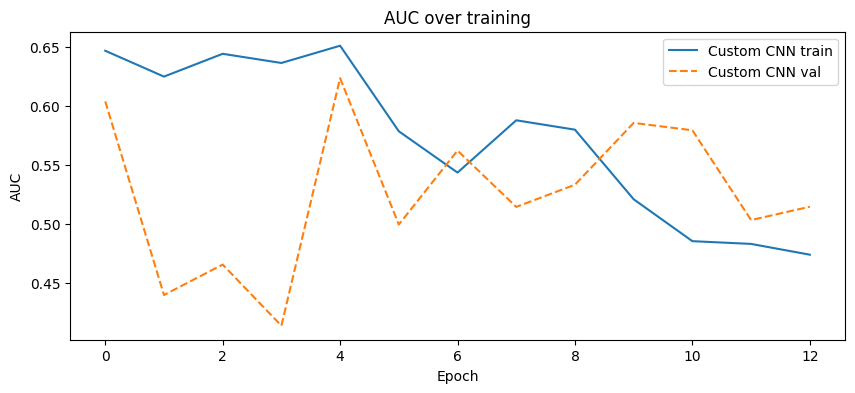

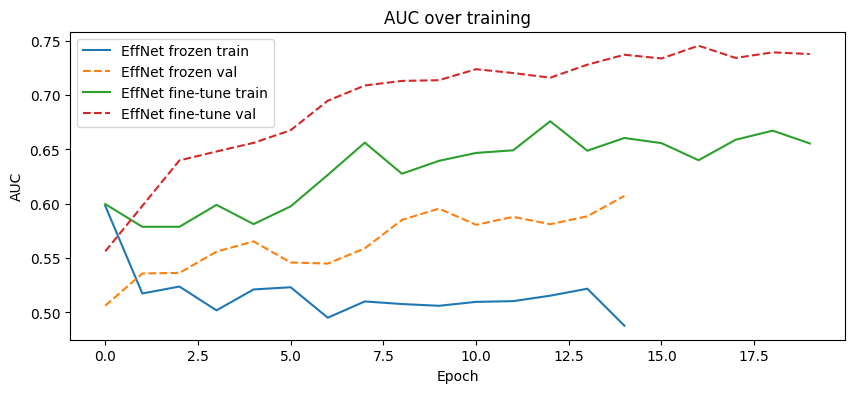

In [15]:
def plot_history(histories, labels, metric="auc"):
    plt.figure(figsize=(10, 4))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=f"{lbl} train")
        plt.plot(h.history[f"val_{metric}"], "--", label=f"{lbl} val")
    plt.xlabel("Epoch"); plt.ylabel(metric.upper()); plt.legend(); plt.title(f"{metric.upper()} over training")
    plt.show()

plot_history([history_cnn], ["Custom CNN"], metric="auc")
plot_history([history_head, history_finetune], ["EffNet frozen", "EffNet fine-tune"], metric="auc")


## 11. Evaluate on the held-out test set

Report precision/recall/F1 on the **Cracked** class specifically —
a false negative here (missed crack) is a structural safety issue, and matters far more than a false positive.


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
=== Custom CNN ===
              precision    recall  f1-score   support

 Non-cracked       0.51      1.00      0.67       226
     Cracked       0.00      0.00      0.00       221

    accuracy                           0.51       447
   macro avg       0.25      0.50      0.34       447
weighted avg       0.26      0.51      0.34       447

Balanced accuracy: 0.5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


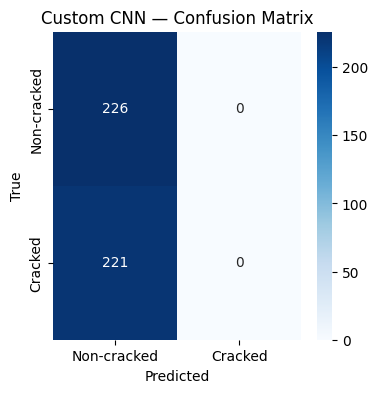

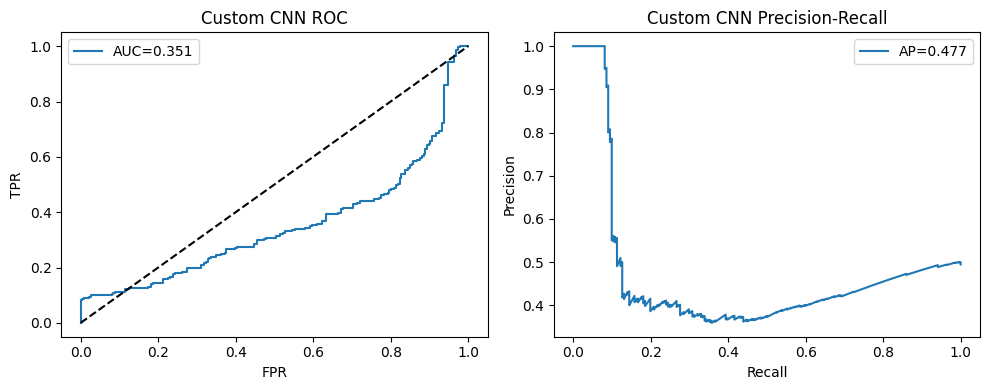

14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step
=== EfficientNetV2-B0 (fine-tuned) ===
              precision    recall  f1-score   support

 Non-cracked       0.62      0.97      0.76       226
     Cracked       0.94      0.40      0.56       221

    accuracy                           0.69       447
   macro avg       0.78      0.69      0.66       447
weighted avg       0.78      0.69      0.66       447

Balanced accuracy: 0.6858206863412485


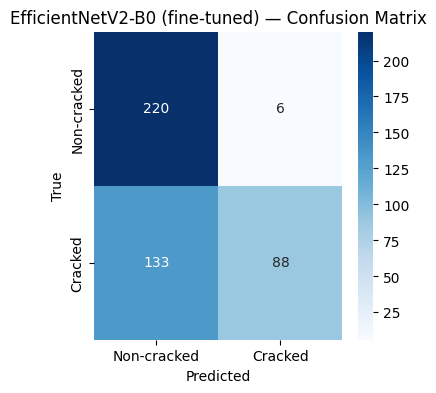

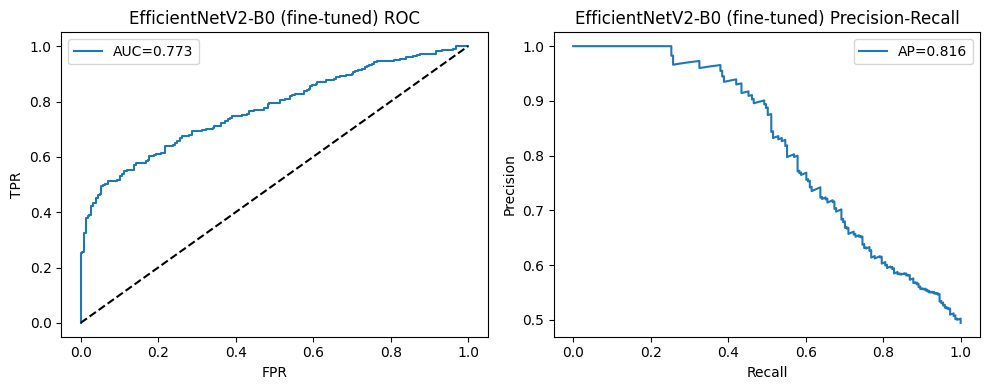

                            model  accuracy  balanced_accuracy  f1_cracked  \
0                      Custom CNN  0.505593           0.500000     0.00000   
1  EfficientNetV2-B0 (fine-tuned)  0.689038           0.685821     0.55873   

    roc_auc    pr_auc  
0  0.351259  0.476728  
1  0.773315  0.815643  


In [16]:
def evaluate_model(model, ds, df, name):
    y_true = df["label"].map(LABEL_MAP).values
    y_prob = model.predict(ds).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred, target_names=["Non-cracked", "Cracked"]))
    print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-cracked", "Cracked"], yticklabels=["Non-cracked", "Cracked"])
    plt.title(f"{name} — Confusion Matrix"); plt.ylabel("True"); plt.xlabel("Predicted")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}"); axes[0].plot([0,1],[0,1],"k--")
    axes[0].set_title(f"{name} ROC"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend()
    axes[1].plot(rec, prec, label=f"AP={pr_auc:.3f}")
    axes[1].set_title(f"{name} Precision-Recall"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
    plt.tight_layout(); plt.show()

    return {
        "model": name,
        "accuracy": (y_pred == y_true).mean(),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_cracked": f1_score(y_true, y_pred, pos_label=1),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
    }

results = []
results.append(evaluate_model(custom_cnn, test_ds, test_df, "Custom CNN"))
results.append(evaluate_model(effnet, test_ds, test_df, "EfficientNetV2-B0 (fine-tuned)"))

results_df = pd.DataFrame(results)
print(results_df)


## 12. Grad-CAM — sanity check that the model looks at cracks, not artifacts

Last conv layer: top_conv


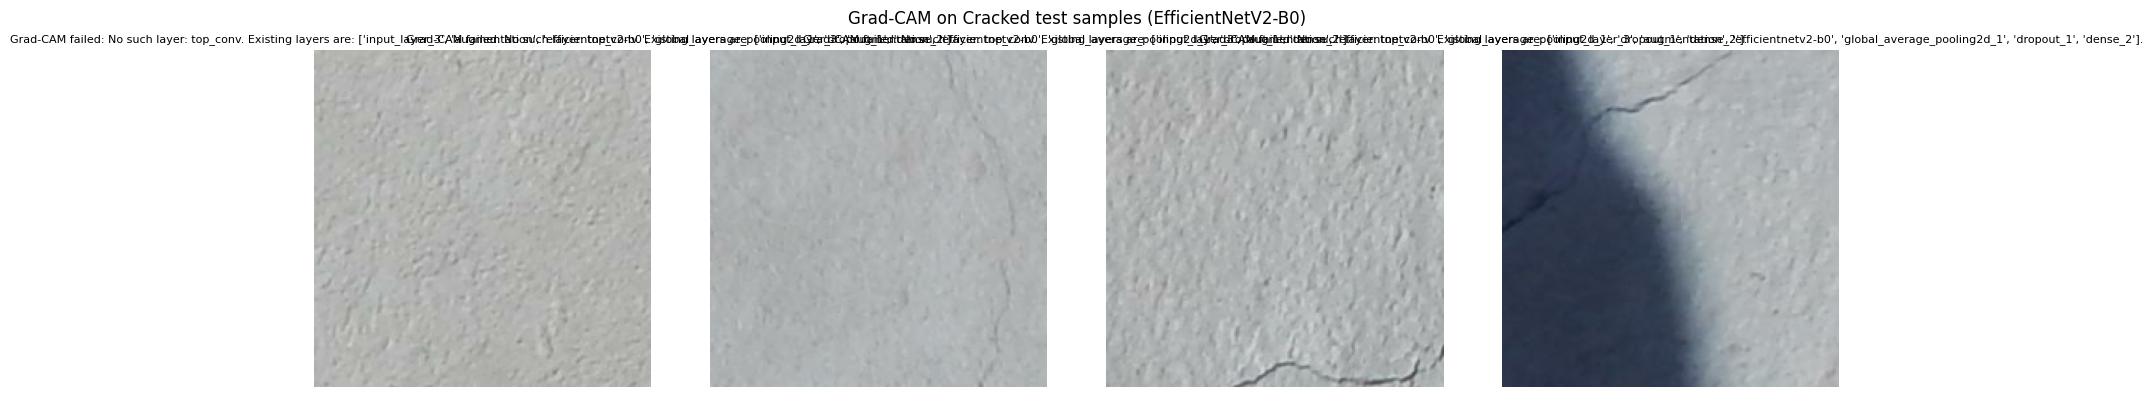

In [17]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array[np.newaxis, ...])
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# Find the last conv layer of the EfficientNet base automatically
last_conv_name = None
for layer in reversed(effnet_base.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_name = layer.name
        break
print("Last conv layer:", last_conv_name)

sample_rows = test_df[test_df.label == "Cracked"].sample(min(4, (test_df.label=="Cracked").sum()), random_state=SEED)
fig, axes = plt.subplots(1, len(sample_rows), figsize=(4*len(sample_rows), 4))
if len(sample_rows) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img = tf.io.read_file(row.filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img_norm = tf.cast(img, tf.float32) / 255.0

    try:
        heatmap = make_gradcam_heatmap(img_norm.numpy(), effnet, last_conv_name)
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
        ax.imshow(img.numpy().astype("uint8"))
        ax.imshow(heatmap_resized, cmap="jet", alpha=0.4)
    except Exception as e:
        ax.imshow(img.numpy().astype("uint8"))
        ax.set_title(f"Grad-CAM failed: {e}", fontsize=8)
    ax.axis("off")
plt.suptitle("Grad-CAM on Cracked test samples (EfficientNetV2-B0)")
plt.tight_layout(); plt.show()


## 13. Save artifacts

In [18]:
# best_model.keras is already saved by ModelCheckpoint during fine-tuning.
# Save label map + summary results alongside it.
import json
with open("label_map.json", "w") as f:
    json.dump(LABEL_MAP, f)

results_df.to_csv("test_set_results.csv", index=False)
print("Saved: best_model.keras, best_custom_cnn.keras, label_map.json, test_set_results.csv")


Saved: best_model.keras, best_custom_cnn.keras, label_map.json, test_set_results.csv
